# Model Monitoring & Drift Detection — BNPL Fraud Detection

Production ML monitoring pipeline that tracks feature drift, concept drift,
model performance degradation, and prediction distribution shifts across
simulated monitoring windows. Includes auto-retrain trigger logic.

## Setup

In [1]:
import sqlite3
import pathlib
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from scipy import stats
from sklearn.metrics import (
    average_precision_score, precision_score, recall_score,
)
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (10, 5)})

DATA_DIR = pathlib.Path("../data")
DB_PATH = DATA_DIR / "bnpl.db"

/opt/anaconda3/lib/python3.11/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [2]:
def load_feature_matrix():
    for ext in ("csv", "parquet"):
        path = DATA_DIR / f"feature_matrix.{ext}"
        if path.exists():
            loader = pd.read_csv if ext == "csv" else pd.read_parquet
            print(f"Loaded feature matrix from {path}")
            return loader(path)

    print("Feature matrix not found — building from bnpl.db")
    conn = sqlite3.connect(DB_PATH)

    orders = pd.read_sql("SELECT * FROM orders", conn)
    plans = pd.read_sql("SELECT * FROM payment_plans", conn)
    installments = pd.read_sql("SELECT * FROM installments", conn)
    segments = pd.read_sql("SELECT * FROM customer_segments_ground_truth", conn)
    conn.close()

    orders["order_date"] = pd.to_datetime(orders["order_date"])

    plan_agg = plans.groupby("order_id").agg(
        num_plans=("plan_id", "count"),
        max_installments=("num_installments", "max"),
    ).reset_index()

    inst_agg = (
        installments.merge(plans[["plan_id", "order_id"]], on="plan_id")
        .groupby("order_id")
        .agg(
            total_due=("amount_due", "sum"),
            avg_due=("amount_due", "mean"),
            max_days_past_due=("days_past_due", "max"),
            avg_days_past_due=("days_past_due", "mean"),
            n_installments=("installment_id", "count"),
            n_late=("days_past_due", lambda x: (x > 0).sum()),
        )
        .reset_index()
    )

    cust_agg = orders.groupby("customer_id").agg(
        cust_order_count=("order_id", "count"),
        cust_total_amount=("order_amount", "sum"),
        cust_avg_amount=("order_amount", "mean"),
    ).reset_index()

    df = orders.merge(plan_agg, on="order_id", how="left")
    df = df.merge(inst_agg, on="order_id", how="left")
    df = df.merge(cust_agg, on="customer_id", how="left")
    df = df.merge(segments, on="customer_id", how="left")

    fraud_labels = pd.read_sql("SELECT order_id, is_fraud FROM order_fraud_labels",
                               sqlite3.connect(DB_PATH))
    df = df.merge(fraud_labels, on="order_id", how="left")
    df["is_fraud"] = df["is_fraud"].fillna(0).astype(int)

    if "channel" in df.columns:
        df["channel_enc"] = df["channel"].astype("category").cat.codes

    df = df.sort_values("order_date").reset_index(drop=True)
    return df


df = load_feature_matrix()
print(f"Shape: {df.shape}")
print(f"Fraud rate: {df['is_fraud'].mean():.4f}")
df.head()

Loaded feature matrix from ../data/feature_matrix.csv
Shape: (155750, 76)
Fraud rate: 0.0607


,order_id,customer_id,merchant_id,order_amount,order_seq,is_fraud,total_installments_before,missed_installments_before,late_installments_before,paid_installments_before,...,channel_in_store_qr,channel_mobile_app,channel_partner_checkout,channel_web,velocity_x_vpn,velocity_x_high_risk,new_account_high_amount,shared_device_x_velocity,fpd_x_velocity,missed_rate_x_amount
0,1,1,158,20.00,1,0,0.0,0.0,0.0,0.0,...,0,0,0,1,0.0,0,0,0.0,0.0,0.0
1,2,1,437,118.08,2,0,6.0,0.0,0.0,6.0,...,0,0,1,0,0.0,0,0,0.0,0.0,0.0
2,3,1,103,32.41,3,0,12.0,0.0,2.0,10.0,...,0,1,0,0,0.0,1,0,0.0,0.0,0.0
3,4,1,282,439.68,4,0,0.0,0.0,0.0,0.0,...,0,1,0,0,0.0,1,0,0.0,0.0,0.0
4,5,1,287,121.25,5,0,0.0,0.0,0.0,0.0,...,0,0,0,1,0.0,0,0,0.0,0.0,0.0


In [3]:
_all_numeric = [
    c for c in df.select_dtypes(include="number").columns
    if c not in ("is_fraud", "order_id", "customer_id", "merchant_id", "plan_id", "installment_id")
]

MODEL_PATH = DATA_DIR / "best_model.joblib"

if MODEL_PATH.exists():
    model = joblib.load(MODEL_PATH)
    print(f"Loaded model from {MODEL_PATH}")
    try:
        model_features = list(model.feature_names_in_)
        for feat in model_features:
            if feat not in df.columns:
                df[feat] = 0
        FEATURE_COLS = model_features
        importances = model.feature_importances_
        top_features = [
            f for f in pd.Series(importances, index=model.feature_names_in_)
            .sort_values(ascending=False).index[:10]
            if f in FEATURE_COLS
        ]
    except Exception:
        FEATURE_COLS = _all_numeric
        top_features = FEATURE_COLS[:10]
else:
    FEATURE_COLS = _all_numeric
    from xgboost import XGBClassifier
    print("No saved model found — training quick XGBClassifier")
    X = df[FEATURE_COLS].fillna(0)
    y = df["is_fraud"]
    model = XGBClassifier(
        n_estimators=100, max_depth=4, learning_rate=0.1,
        scale_pos_weight=(y == 0).sum() / max((y == 1).sum(), 1),
        use_label_encoder=False, eval_metric="aucpr", random_state=42,
    )
    model.fit(X, y, verbose=False)
    importances = model.feature_importances_
    top_features = (
        pd.Series(importances, index=FEATURE_COLS)
        .sort_values(ascending=False)
        .index[:10]
        .tolist()
    )

if not top_features:
    top_features = FEATURE_COLS[:10]

print(f"Monitoring {len(top_features)} features: {top_features}")

Loaded model from ../data/best_model.joblib
Monitoring 10 features: ['credit_score', 'annual_income', 'account_age_days', 'merchant_fraud_rate', 'merchant_order_volume', 'recent_5_dpd_mean', 'exposure_at_order', 'days_since_last_order', 'amount_per_installment', 'income_to_order_ratio']


In [4]:
if "order_date" in df.columns:
    df["order_date"] = pd.to_datetime(df["order_date"])
    df = df.sort_values("order_date").reset_index(drop=True)

n = len(df)
ref_end = n // 2

df_reference = df.iloc[:ref_end].copy()
df_monitor = df.iloc[ref_end:].copy()

N_WINDOWS = 6
window_size = len(df_monitor) // N_WINDOWS
windows = {}
for i in range(N_WINDOWS):
    start = i * window_size
    end = (i + 1) * window_size if i < N_WINDOWS - 1 else len(df_monitor)
    windows[f"W{i+1}"] = df_monitor.iloc[start:end].copy()

print(f"Reference period: {len(df_reference):,} rows")
for wname, wdf in windows.items():
    date_range = ""
    if "order_date" in wdf.columns:
        date_range = f"  ({wdf['order_date'].min().date()} → {wdf['order_date'].max().date()})"
    print(f"  {wname}: {len(wdf):,} rows{date_range}")

Reference period: 77,875 rows
  W1: 12,979 rows
  W2: 12,979 rows
  W3: 12,979 rows
  W4: 12,979 rows
  W5: 12,979 rows
  W6: 12,980 rows


## Feature Drift

The Kolmogorov-Smirnov test compares feature distributions between a reference window and each monitoring window. A high KS statistic with low p-value means the feature's distribution has shifted — which may degrade model performance even if fraud patterns haven't changed.

In [5]:
def compute_feature_drift(reference, monitoring_windows, features, ks_threshold=0.1, p_threshold=0.05):
    results = []
    for feat in features:
        ref_vals = reference[feat].dropna()
        for wname, wdf in monitoring_windows.items():
            mon_vals = wdf[feat].dropna()
            ks_stat, p_val = stats.ks_2samp(ref_vals, mon_vals)
            drift = ks_stat > ks_threshold and p_val < p_threshold
            results.append({
                "feature": feat, "window": wname,
                "ks_stat": round(ks_stat, 4), "p_value": round(p_val, 6),
                "drift_detected": drift,
            })
    return pd.DataFrame(results)


drift_df = compute_feature_drift(df_reference, windows, top_features)
drift_df["drift_flag"] = drift_df["drift_detected"].map({True: "Y", False: "N"})

summary = drift_df.pivot_table(index="feature", columns="window", values="ks_stat", aggfunc="first")
drift_flags = drift_df.pivot_table(index="feature", columns="window", values="drift_flag", aggfunc="first")

print("KS Statistics by Feature × Window")
display(summary.round(4))
print("\nDrift Detected (Y/N)")
display(drift_flags)

KS Statistics by Feature × Window


window,W1,W2,W3,W4,W5,W6
feature,,,,,,
account_age_days,0.0140,0.0057,0.0078,0.0078,0.0081,0.0075
amount_per_installment,0.0046,0.0119,0.0143,0.0132,0.0060,0.0065
annual_income,0.0134,0.0122,0.0133,0.0127,0.0146,0.0159
credit_score,0.0289,0.0148,0.0135,0.0183,0.0130,0.0100
days_since_last_order,0.0050,0.0028,0.0087,0.0059,0.0064,0.0049
exposure_at_order,0.0066,0.0128,0.0182,0.0158,0.0062,0.0064
income_to_order_ratio,0.0059,0.0111,0.0140,0.0114,0.0065,0.0099
merchant_fraud_rate,0.0064,0.0106,0.0099,0.0119,0.0096,0.0052
merchant_order_volume,0.0074,0.0128,0.0070,0.0111,0.0069,0.0046



Drift Detected (Y/N)


window,W1,W2,W3,W4,W5,W6
feature,,,,,,
account_age_days,N,N,N,N,N,N
amount_per_installment,N,N,N,N,N,N
annual_income,N,N,N,N,N,N
credit_score,N,N,N,N,N,N
days_since_last_order,N,N,N,N,N,N
exposure_at_order,N,N,N,N,N,N
income_to_order_ratio,N,N,N,N,N,N
merchant_fraud_rate,N,N,N,N,N,N
merchant_order_volume,N,N,N,N,N,N


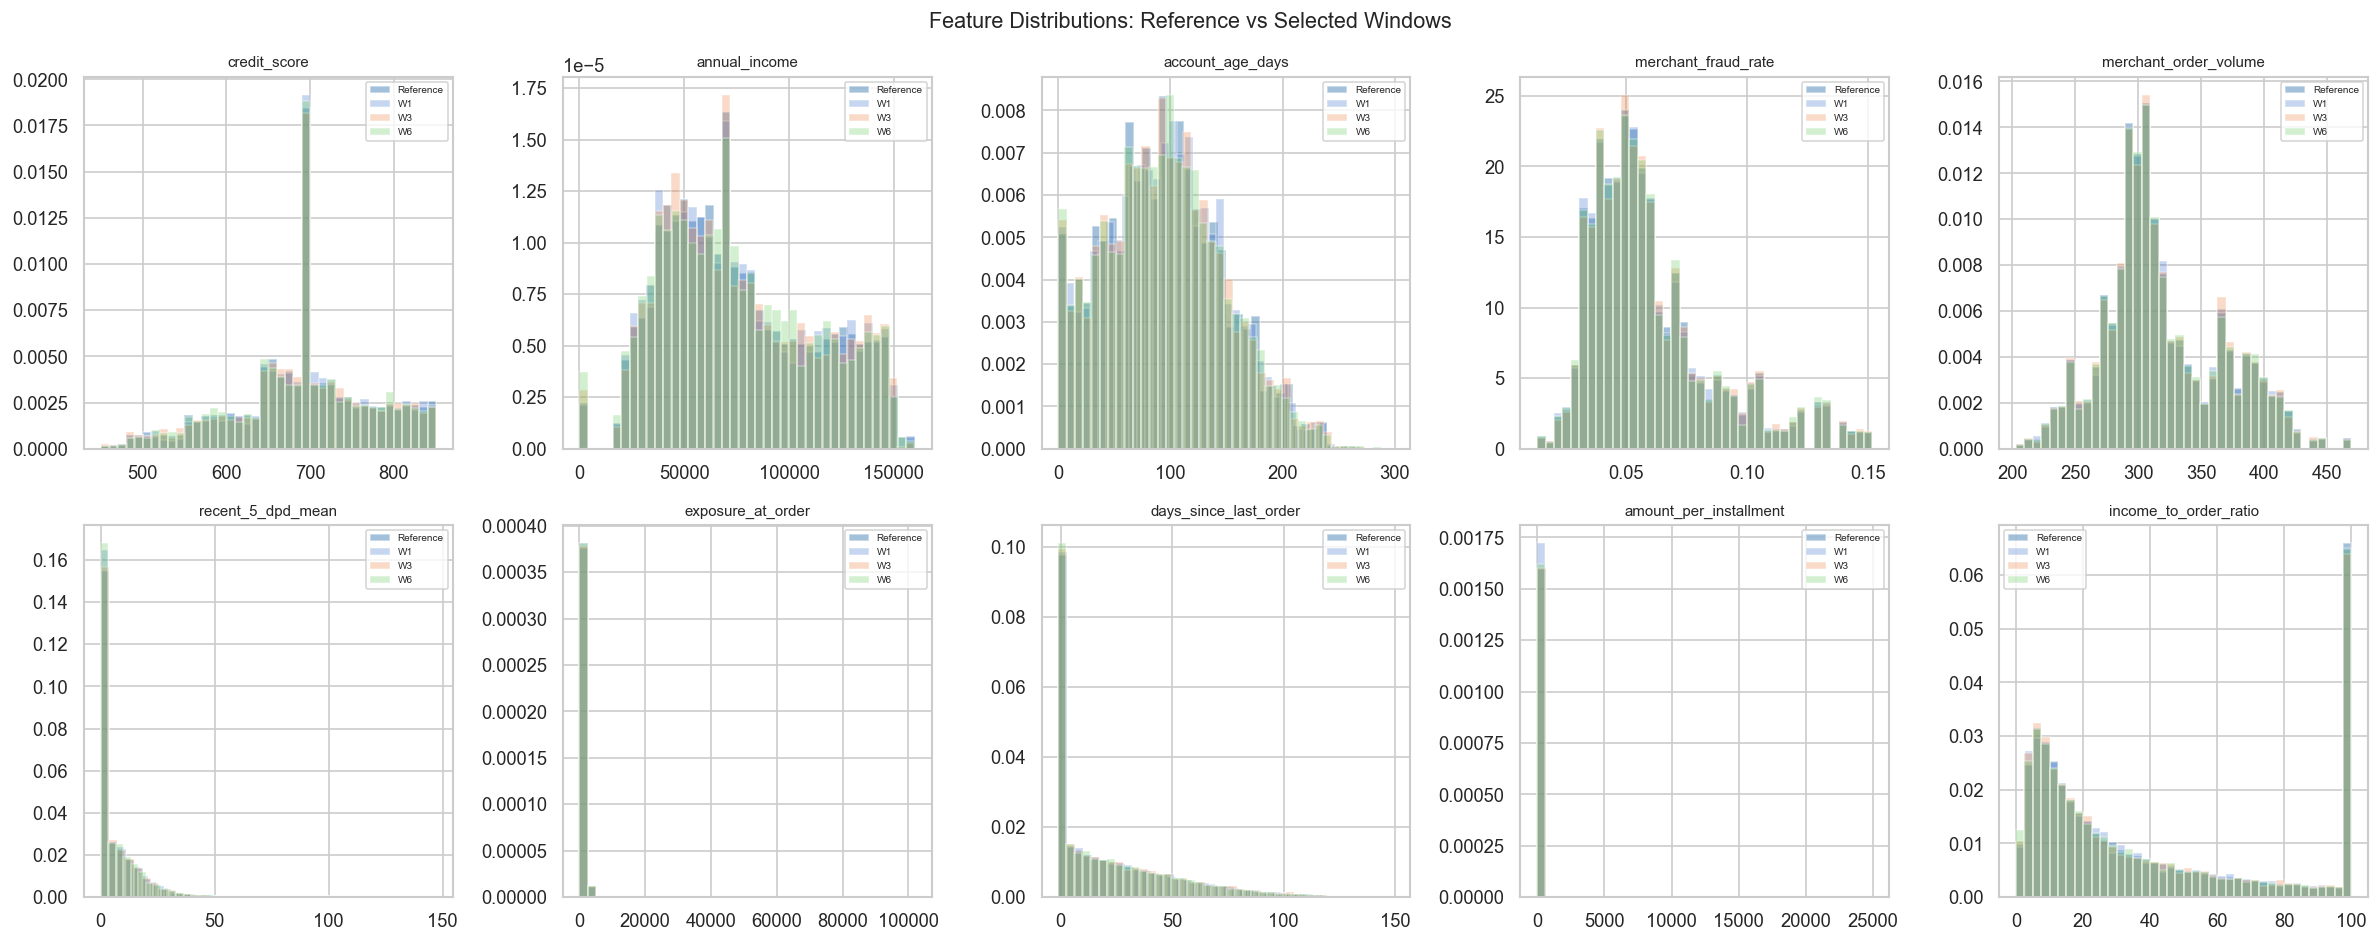

In [6]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.ravel()

for idx, feat in enumerate(top_features[:10]):
    ax = axes[idx]
    ref_vals = df_reference[feat].dropna()
    ax.hist(ref_vals, bins=40, alpha=0.5, density=True, label="Reference", color="steelblue")
    for wname in ["W1", "W3", "W6"]:
        mon_vals = windows[wname][feat].dropna()
        ax.hist(mon_vals, bins=40, alpha=0.3, density=True, label=wname)
    ax.set_title(feat, fontsize=9)
    ax.legend(fontsize=6)

plt.suptitle("Feature Distributions: Reference vs Selected Windows", fontsize=13)
plt.tight_layout()
plt.show()

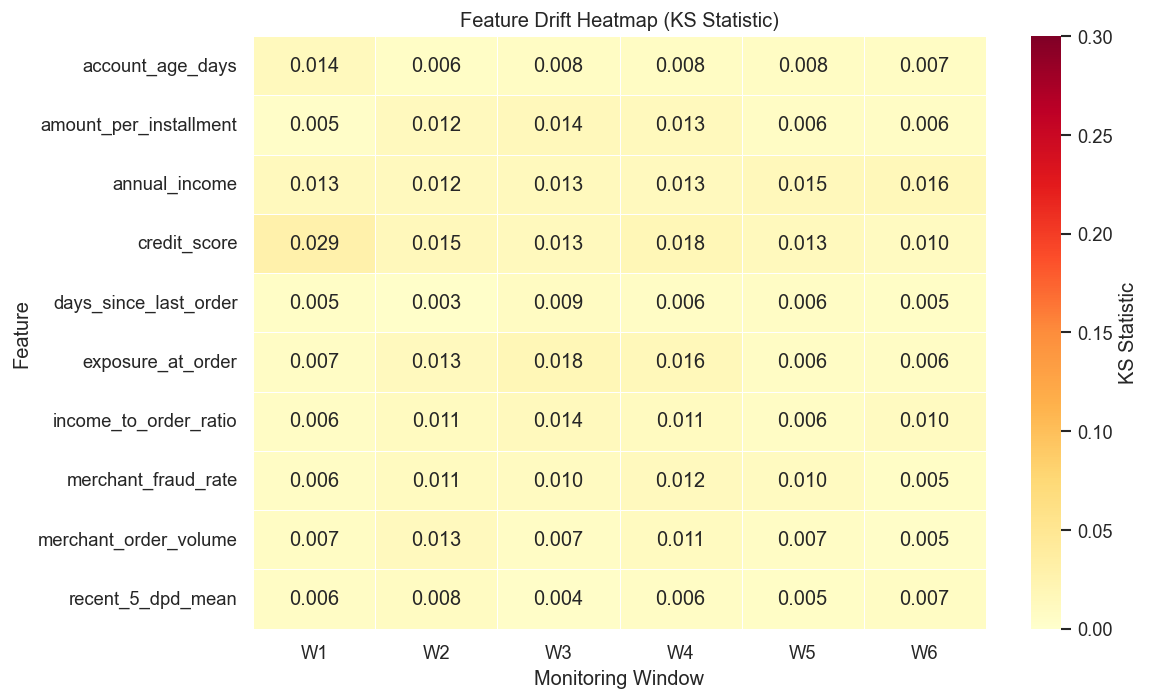

In [7]:
heatmap_data = drift_df.pivot_table(index="feature", columns="window", values="ks_stat", aggfunc="first")

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    heatmap_data, annot=True, fmt=".3f", cmap="YlOrRd",
    linewidths=0.5, ax=ax, vmin=0, vmax=0.3,
    cbar_kws={"label": "KS Statistic"},
)
ax.set_title("Feature Drift Heatmap (KS Statistic)")
ax.set_ylabel("Feature")
ax.set_xlabel("Monitoring Window")
plt.tight_layout()
plt.show()

## Concept Drift

Concept drift means the relationship between features and the target has changed — fraud patterns evolved. Even if feature distributions are stable, the model may lose accuracy if the underlying fraud typology shifts.

In [8]:
def compute_concept_drift(reference, monitoring_windows):
    ref_fraud_rate = reference["is_fraud"].mean()
    ref_std = reference["is_fraud"].std()
    upper_limit = ref_fraud_rate + 2 * ref_std
    lower_limit = ref_fraud_rate - 2 * ref_std

    results = []
    for wname, wdf in monitoring_windows.items():
        fraud_rate = wdf["is_fraud"].mean()
        n_fraud = wdf["is_fraud"].sum()
        n_total = len(wdf)

        ref_n_fraud = reference["is_fraud"].sum()
        ref_n_total = len(reference)
        observed = np.array([[n_fraud, n_total - n_fraud], [ref_n_fraud, ref_n_total - ref_n_fraud]])
        chi2, p_val, _, _ = stats.chi2_contingency(observed)

        outside_limits = fraud_rate > upper_limit or fraud_rate < lower_limit
        results.append({
            "window": wname, "fraud_rate": fraud_rate,
            "chi2": round(chi2, 4), "p_value": round(p_val, 6),
            "outside_control_limits": outside_limits,
        })

    return pd.DataFrame(results), ref_fraud_rate, upper_limit, lower_limit


concept_df, ref_fraud_rate, upper_cl, lower_cl = compute_concept_drift(df_reference, windows)
display(concept_df)

,window,fraud_rate,chi2,p_value,outside_control_limits
0,W1,0.055705,2.6603,0.102880,False
1,W2,0.065105,6.3214,0.011929,False
2,W3,0.061638,0.9617,0.326769,False
3,W4,0.064643,5.3381,0.020864,False
4,W5,0.063641,3.4900,0.061739,False
5,W6,0.061248,0.6520,0.419412,False


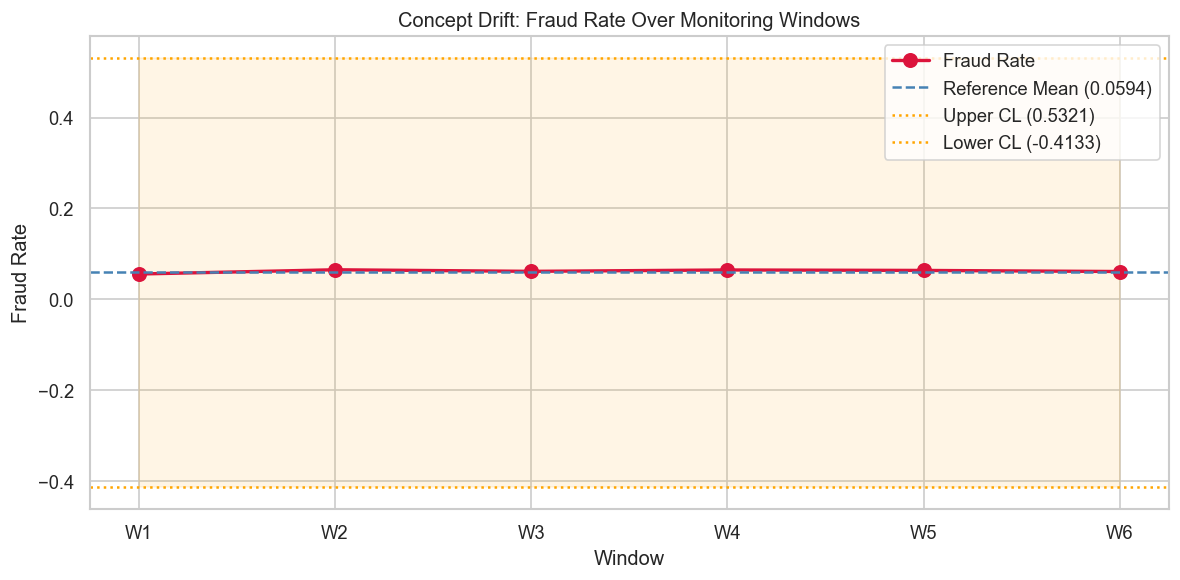

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
window_names = concept_df["window"]
fraud_rates = concept_df["fraud_rate"]

ax.plot(window_names, fraud_rates, "o-", color="crimson", linewidth=2, markersize=8, label="Fraud Rate")
ax.axhline(ref_fraud_rate, color="steelblue", linestyle="--", linewidth=1.5, label=f"Reference Mean ({ref_fraud_rate:.4f})")
ax.axhline(upper_cl, color="orange", linestyle=":", linewidth=1.5, label=f"Upper CL ({upper_cl:.4f})")
ax.axhline(lower_cl, color="orange", linestyle=":", linewidth=1.5, label=f"Lower CL ({lower_cl:.4f})")
ax.fill_between(window_names, lower_cl, upper_cl, alpha=0.1, color="orange")

for _, row in concept_df[concept_df["outside_control_limits"]].iterrows():
    ax.annotate("ALERT", (row["window"], row["fraud_rate"]),
                textcoords="offset points", xytext=(0, 12),
                fontsize=9, color="red", fontweight="bold", ha="center")

ax.set_title("Concept Drift: Fraud Rate Over Monitoring Windows")
ax.set_xlabel("Window")
ax.set_ylabel("Fraud Rate")
ax.legend()
plt.tight_layout()
plt.show()

## Performance Degradation

The most direct signal: is the model's PR-AUC declining over time? A 5+ percentage point drop from baseline triggers investigation.

In [10]:
def score_windows(model, reference, monitoring_windows, feature_cols):
    def _metrics(y_true, y_prob):
        y_pred = (y_prob >= 0.5).astype(int)
        pr_auc = average_precision_score(y_true, y_prob) if y_true.sum() > 0 else 0.0
        prec = precision_score(y_true, y_pred, zero_division=0)
        rec = recall_score(y_true, y_pred, zero_division=0)
        return pr_auc, prec, rec

    X_ref = reference[feature_cols].fillna(0)
    y_ref = reference["is_fraud"]
    ref_proba = model.predict_proba(X_ref)[:, 1]
    baseline_pr_auc, baseline_prec, baseline_rec = _metrics(y_ref, ref_proba)

    rows = [{"window": "Reference", "pr_auc": baseline_pr_auc,
             "precision": baseline_prec, "recall": baseline_rec}]
    window_probas = {}

    for wname, wdf in monitoring_windows.items():
        X_w = wdf[feature_cols].fillna(0)
        y_w = wdf["is_fraud"]
        proba = model.predict_proba(X_w)[:, 1]
        window_probas[wname] = proba
        pr_auc, prec, rec = _metrics(y_w, proba)
        rows.append({"window": wname, "pr_auc": pr_auc,
                     "precision": prec, "recall": rec})

    return pd.DataFrame(rows), baseline_pr_auc, ref_proba, window_probas


perf_df, baseline_pr_auc, ref_proba, window_probas = score_windows(
    model, df_reference, windows, FEATURE_COLS,
)

perf_df["pr_auc_drop_%"] = ((baseline_pr_auc - perf_df["pr_auc"]) / baseline_pr_auc * 100).round(2)
perf_df["perf_alert"] = perf_df["pr_auc_drop_%"] > 5
display(perf_df)

,window,pr_auc,precision,recall,pr_auc_drop_%,perf_alert
0,Reference,0.804871,0.565429,0.905297,0.00,False
1,W1,0.809023,0.557659,0.896266,-0.52,False
2,W2,0.822413,0.588324,0.918343,-2.18,False
3,W3,0.791030,0.554455,0.910000,1.72,False
4,W4,0.616799,0.503858,0.778308,23.37,True
5,W5,0.631917,0.510188,0.788136,21.49,True
6,W6,0.609946,0.501184,0.798742,24.22,True


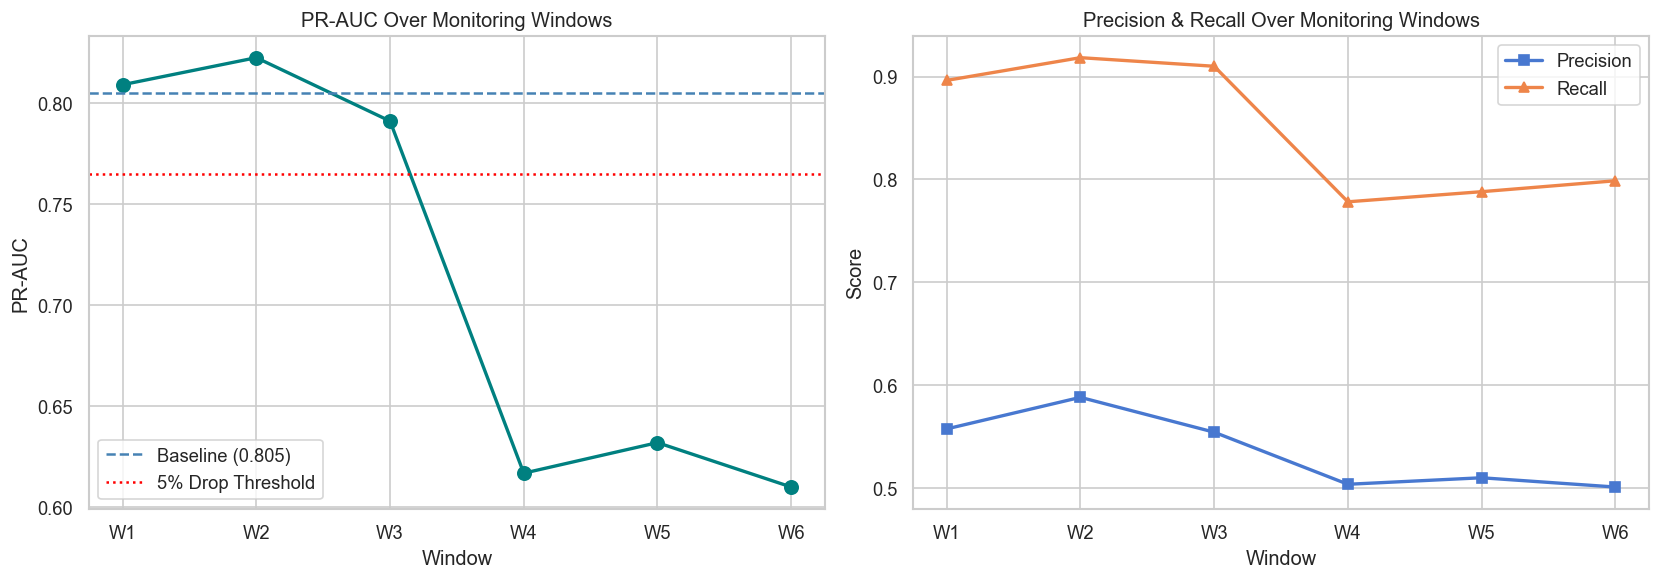

In [11]:
mon_perf = perf_df[perf_df["window"] != "Reference"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(mon_perf["window"], mon_perf["pr_auc"], "o-", color="teal", linewidth=2, markersize=8)
ax.axhline(baseline_pr_auc, color="steelblue", linestyle="--", label=f"Baseline ({baseline_pr_auc:.3f})")
ax.axhline(baseline_pr_auc * 0.95, color="red", linestyle=":", label="5% Drop Threshold")
ax.set_title("PR-AUC Over Monitoring Windows")
ax.set_xlabel("Window")
ax.set_ylabel("PR-AUC")
ax.legend()

ax = axes[1]
ax.plot(mon_perf["window"], mon_perf["precision"], "s-", label="Precision", linewidth=2)
ax.plot(mon_perf["window"], mon_perf["recall"], "^-", label="Recall", linewidth=2)
ax.set_title("Precision & Recall Over Monitoring Windows")
ax.set_xlabel("Window")
ax.set_ylabel("Score")
ax.legend()

plt.tight_layout()
plt.show()

## Prediction Score Distribution

Shifts in the model's score distribution (even without label data) can indicate problems. If the model suddenly scores most transactions as high-risk, something has changed in the input data.

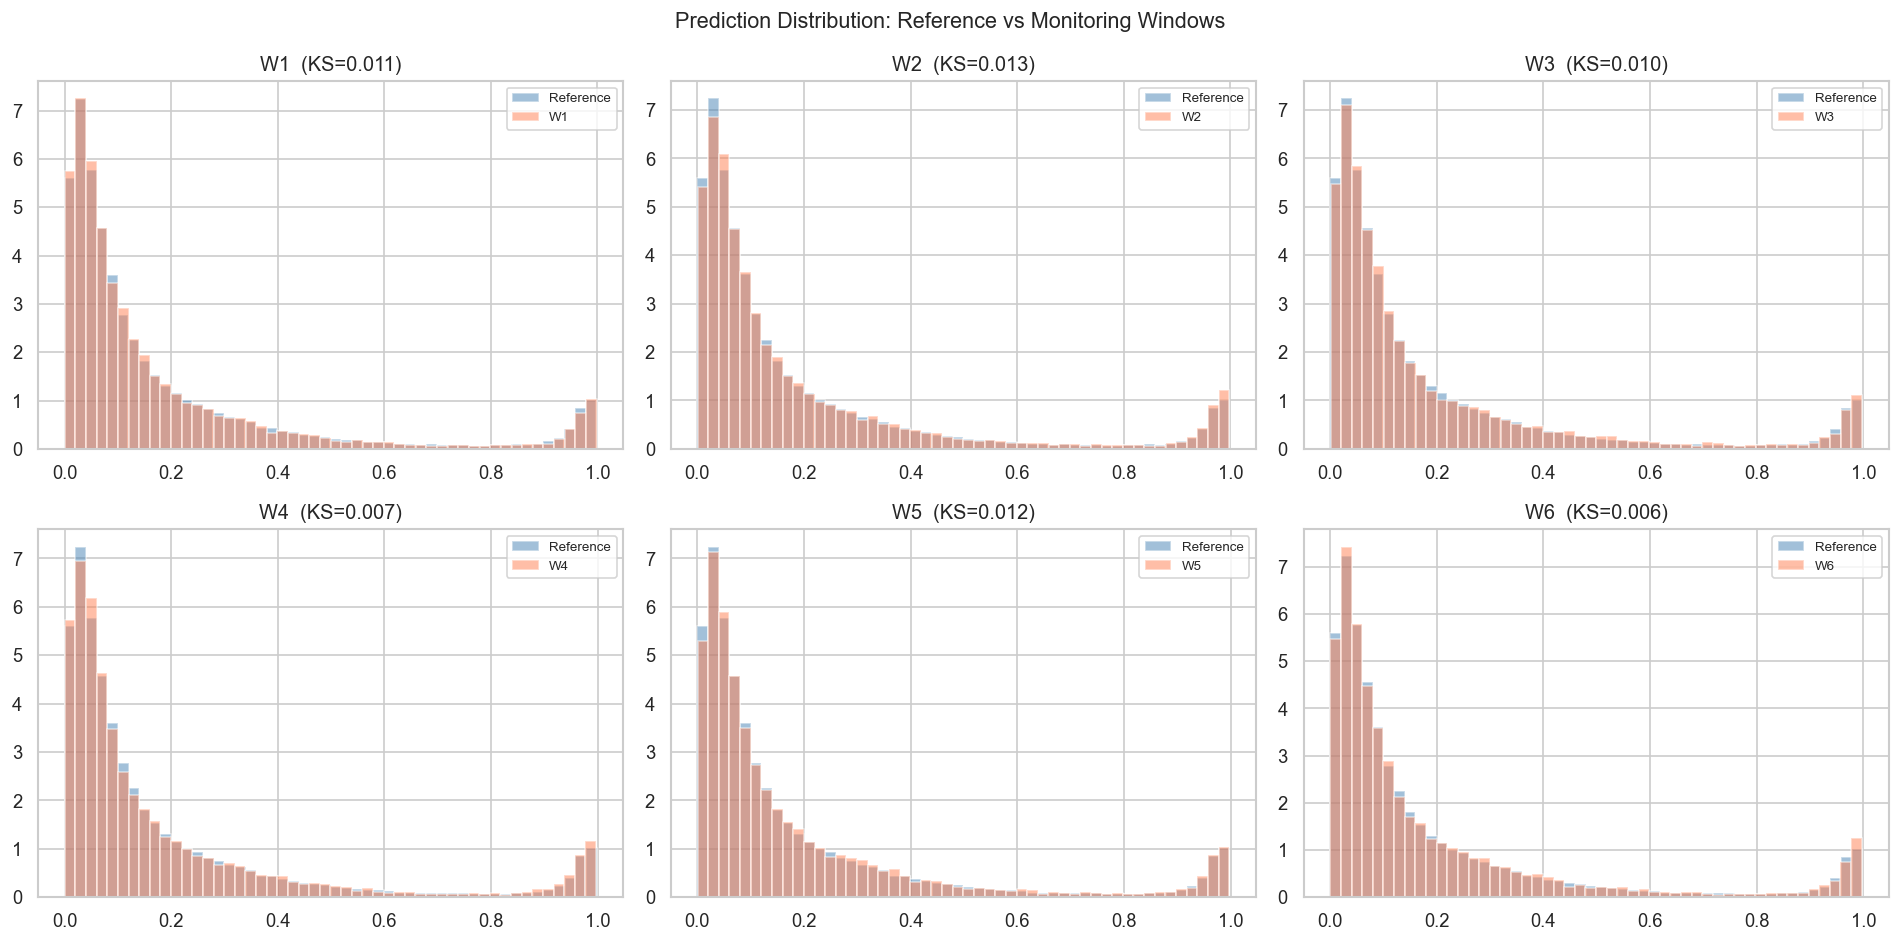

,window,ks_stat,p_value,mean_score
0,W1,0.0111,0.130167,0.1807
1,W2,0.0133,0.038713,0.1918
2,W3,0.0095,0.264785,0.1889
3,W4,0.0074,0.578226,0.1901
4,W5,0.0122,0.073979,0.1899
5,W6,0.0062,0.781621,0.1876


In [12]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.ravel()

pred_drift_rows = []
for i, (wname, proba) in enumerate(window_probas.items()):
    ax = axes[i]
    ax.hist(ref_proba, bins=50, alpha=0.5, density=True, label="Reference", color="steelblue")
    ax.hist(proba, bins=50, alpha=0.5, density=True, label=wname, color="coral")
    ks_stat, p_val = stats.ks_2samp(ref_proba, proba)
    pred_drift_rows.append({
        "window": wname, "ks_stat": round(ks_stat, 4),
        "p_value": round(p_val, 6), "mean_score": round(proba.mean(), 4),
    })
    ax.set_title(f"{wname}  (KS={ks_stat:.3f})")
    ax.legend(fontsize=8)

plt.suptitle("Prediction Distribution: Reference vs Monitoring Windows", fontsize=13)
plt.tight_layout()
plt.show()

pred_drift_df = pd.DataFrame(pred_drift_rows)
display(pred_drift_df)

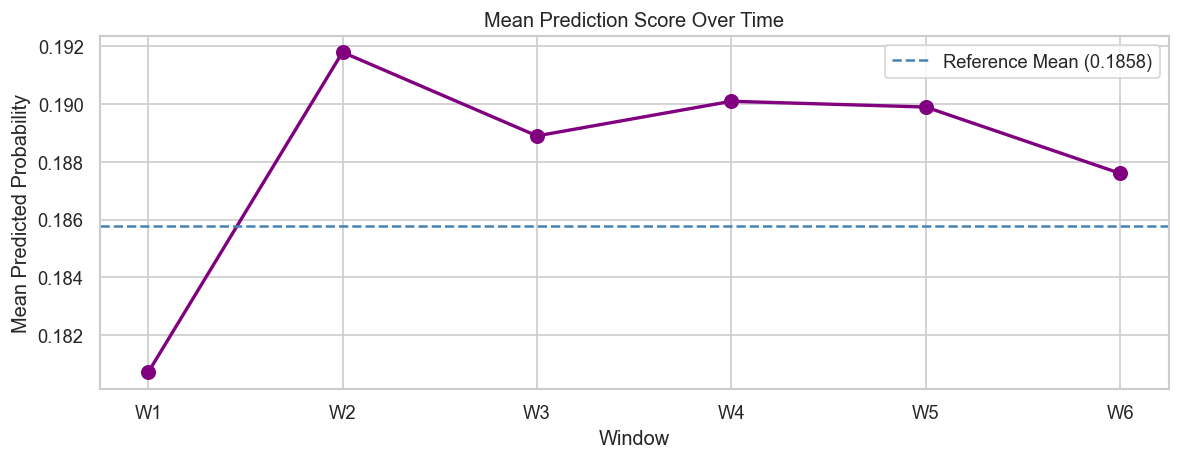

In [13]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(pred_drift_df["window"], pred_drift_df["mean_score"], "o-", color="purple", linewidth=2, markersize=8)
ax.axhline(ref_proba.mean(), color="steelblue", linestyle="--", label=f"Reference Mean ({ref_proba.mean():.4f})")
ax.set_title("Mean Prediction Score Over Time")
ax.set_xlabel("Window")
ax.set_ylabel("Mean Predicted Probability")
ax.legend()
plt.tight_layout()
plt.show()

## Auto-Retrain Triggers

In production, retraining is expensive and disruptive. The trigger logic fires only when multiple drift signals co-occur — a single drifted feature alone isn't sufficient.

In [14]:
def check_retrain_triggers(drift_df, perf_df, concept_df, baseline_pr_auc,
                           ks_threshold=0.1, consec_windows=2, pr_auc_drop_pct=5):
    triggers = {"feature_drift": False, "performance_drop": False, "concept_drift": False}
    details = []

    window_names = sorted(drift_df["window"].unique())
    for feat in drift_df["feature"].unique():
        feat_data = drift_df[drift_df["feature"] == feat].set_index("window")
        consecutive = 0
        for w in window_names:
            if w in feat_data.index and feat_data.loc[w, "ks_stat"] > ks_threshold:
                consecutive += 1
                if consecutive >= consec_windows:
                    triggers["feature_drift"] = True
                    details.append(f"Feature '{feat}': KS > {ks_threshold} for {consecutive} consecutive windows")
                    break
            else:
                consecutive = 0

    mon_perf = perf_df[perf_df["window"] != "Reference"]
    for _, row in mon_perf.iterrows():
        drop = (baseline_pr_auc - row["pr_auc"]) / baseline_pr_auc * 100
        if drop > pr_auc_drop_pct:
            triggers["performance_drop"] = True
            details.append(f"PR-AUC dropped {drop:.1f}% in {row['window']}")

    consec_concept = 0
    for _, row in concept_df.iterrows():
        if row["outside_control_limits"]:
            consec_concept += 1
            if consec_concept >= consec_windows:
                triggers["concept_drift"] = True
                details.append(f"Fraud rate outside control limits for {consec_concept}+ windows")
                break
        else:
            consec_concept = 0

    should_retrain = any(triggers.values())
    return should_retrain, triggers, details


should_retrain, triggers, trigger_details = check_retrain_triggers(
    drift_df, perf_df, concept_df, baseline_pr_auc,
)

print("=" * 60)
print(f"RETRAIN RECOMMENDED: {'YES' if should_retrain else 'NO'}")
print("=" * 60)
for k, v in triggers.items():
    print(f"  {k:25s}: {'TRIGGERED' if v else 'OK'}")
if trigger_details:
    print("\nDetails:")
    for d in trigger_details:
        print(f"  • {d}")

RETRAIN RECOMMENDED: YES
  feature_drift            : OK
  performance_drop         : TRIGGERED
  concept_drift            : OK

Details:
  • PR-AUC dropped 23.4% in W4
  • PR-AUC dropped 21.5% in W5
  • PR-AUC dropped 24.2% in W6


In [15]:
print("Simulating per-window retrain trigger checks:\n")
window_names = sorted(windows.keys())
for i, wname in enumerate(window_names, 1):
    partial_windows = {k: windows[k] for k in window_names[:i]}
    partial_drift = drift_df[drift_df["window"].isin(partial_windows.keys())]
    partial_concept = concept_df[concept_df["window"].isin(partial_windows.keys())]
    partial_perf = perf_df[perf_df["window"].isin(list(partial_windows.keys()) + ["Reference"])]

    retrain, trigs, dets = check_retrain_triggers(
        partial_drift, partial_perf, partial_concept, baseline_pr_auc,
    )
    status = "RETRAIN" if retrain else "OK"
    active = [k for k, v in trigs.items() if v]
    print(f"  After {wname}: [{status}]  {', '.join(active) if active else 'all clear'}")

Simulating per-window retrain trigger checks:

  After W1: [OK]  all clear
  After W2: [OK]  all clear
  After W3: [OK]  all clear
  After W4: [RETRAIN]  performance_drop
  After W5: [RETRAIN]  performance_drop
  After W6: [RETRAIN]  performance_drop


In [16]:
if should_retrain:
    print("Demonstrating retrain on expanded data...\n")

    first_trigger_window = None
    for i, wname in enumerate(window_names, 1):
        partial_windows = {k: windows[k] for k in window_names[:i]}
        partial_drift = drift_df[drift_df["window"].isin(partial_windows.keys())]
        partial_concept = concept_df[concept_df["window"].isin(partial_windows.keys())]
        partial_perf = perf_df[perf_df["window"].isin(list(partial_windows.keys()) + ["Reference"])]
        retrain, _, _ = check_retrain_triggers(
            partial_drift, partial_perf, partial_concept, baseline_pr_auc,
        )
        if retrain:
            first_trigger_window = wname
            break

    if first_trigger_window:
        trigger_idx = window_names.index(first_trigger_window)
        retrain_data = pd.concat(
            [df_reference] + [windows[w] for w in window_names[:trigger_idx + 1]]
        )
        eval_windows = {w: windows[w] for w in window_names[trigger_idx + 1:]}

        if eval_windows:
            from xgboost import XGBClassifier

            X_retrain = retrain_data[FEATURE_COLS].fillna(0)
            y_retrain = retrain_data["is_fraud"]
            new_model = XGBClassifier(
                n_estimators=100, max_depth=4, learning_rate=0.1,
                scale_pos_weight=(y_retrain == 0).sum() / max((y_retrain == 1).sum(), 1),
                use_label_encoder=False, eval_metric="aucpr", random_state=42,
            )
            new_model.fit(X_retrain, y_retrain, verbose=False)

            print(f"Retrained after {first_trigger_window} on {len(retrain_data):,} rows")
            print(f"Evaluating on remaining windows: {list(eval_windows.keys())}\n")

            for wname, wdf in eval_windows.items():
                X_w = wdf[FEATURE_COLS].fillna(0)
                y_w = wdf["is_fraud"]
                old_proba = model.predict_proba(X_w)[:, 1]
                new_proba = new_model.predict_proba(X_w)[:, 1]
                old_pr = average_precision_score(y_w, old_proba) if y_w.sum() > 0 else 0
                new_pr = average_precision_score(y_w, new_proba) if y_w.sum() > 0 else 0
                delta = new_pr - old_pr
                print(f"  {wname}: Old PR-AUC={old_pr:.4f}  New PR-AUC={new_pr:.4f}  Δ={delta:+.4f}")
        else:
            print("No remaining windows to evaluate after retrain trigger.")
else:
    print("No retrain triggered — model is stable across all windows.")

Demonstrating retrain on expanded data...

Retrained after W4 on 129,791 rows
Evaluating on remaining windows: ['W5', 'W6']

  W5: Old PR-AUC=0.6319  New PR-AUC=0.6349  Δ=+0.0030
  W6: Old PR-AUC=0.6099  New PR-AUC=0.6119  Δ=+0.0020


## Dashboard Summary

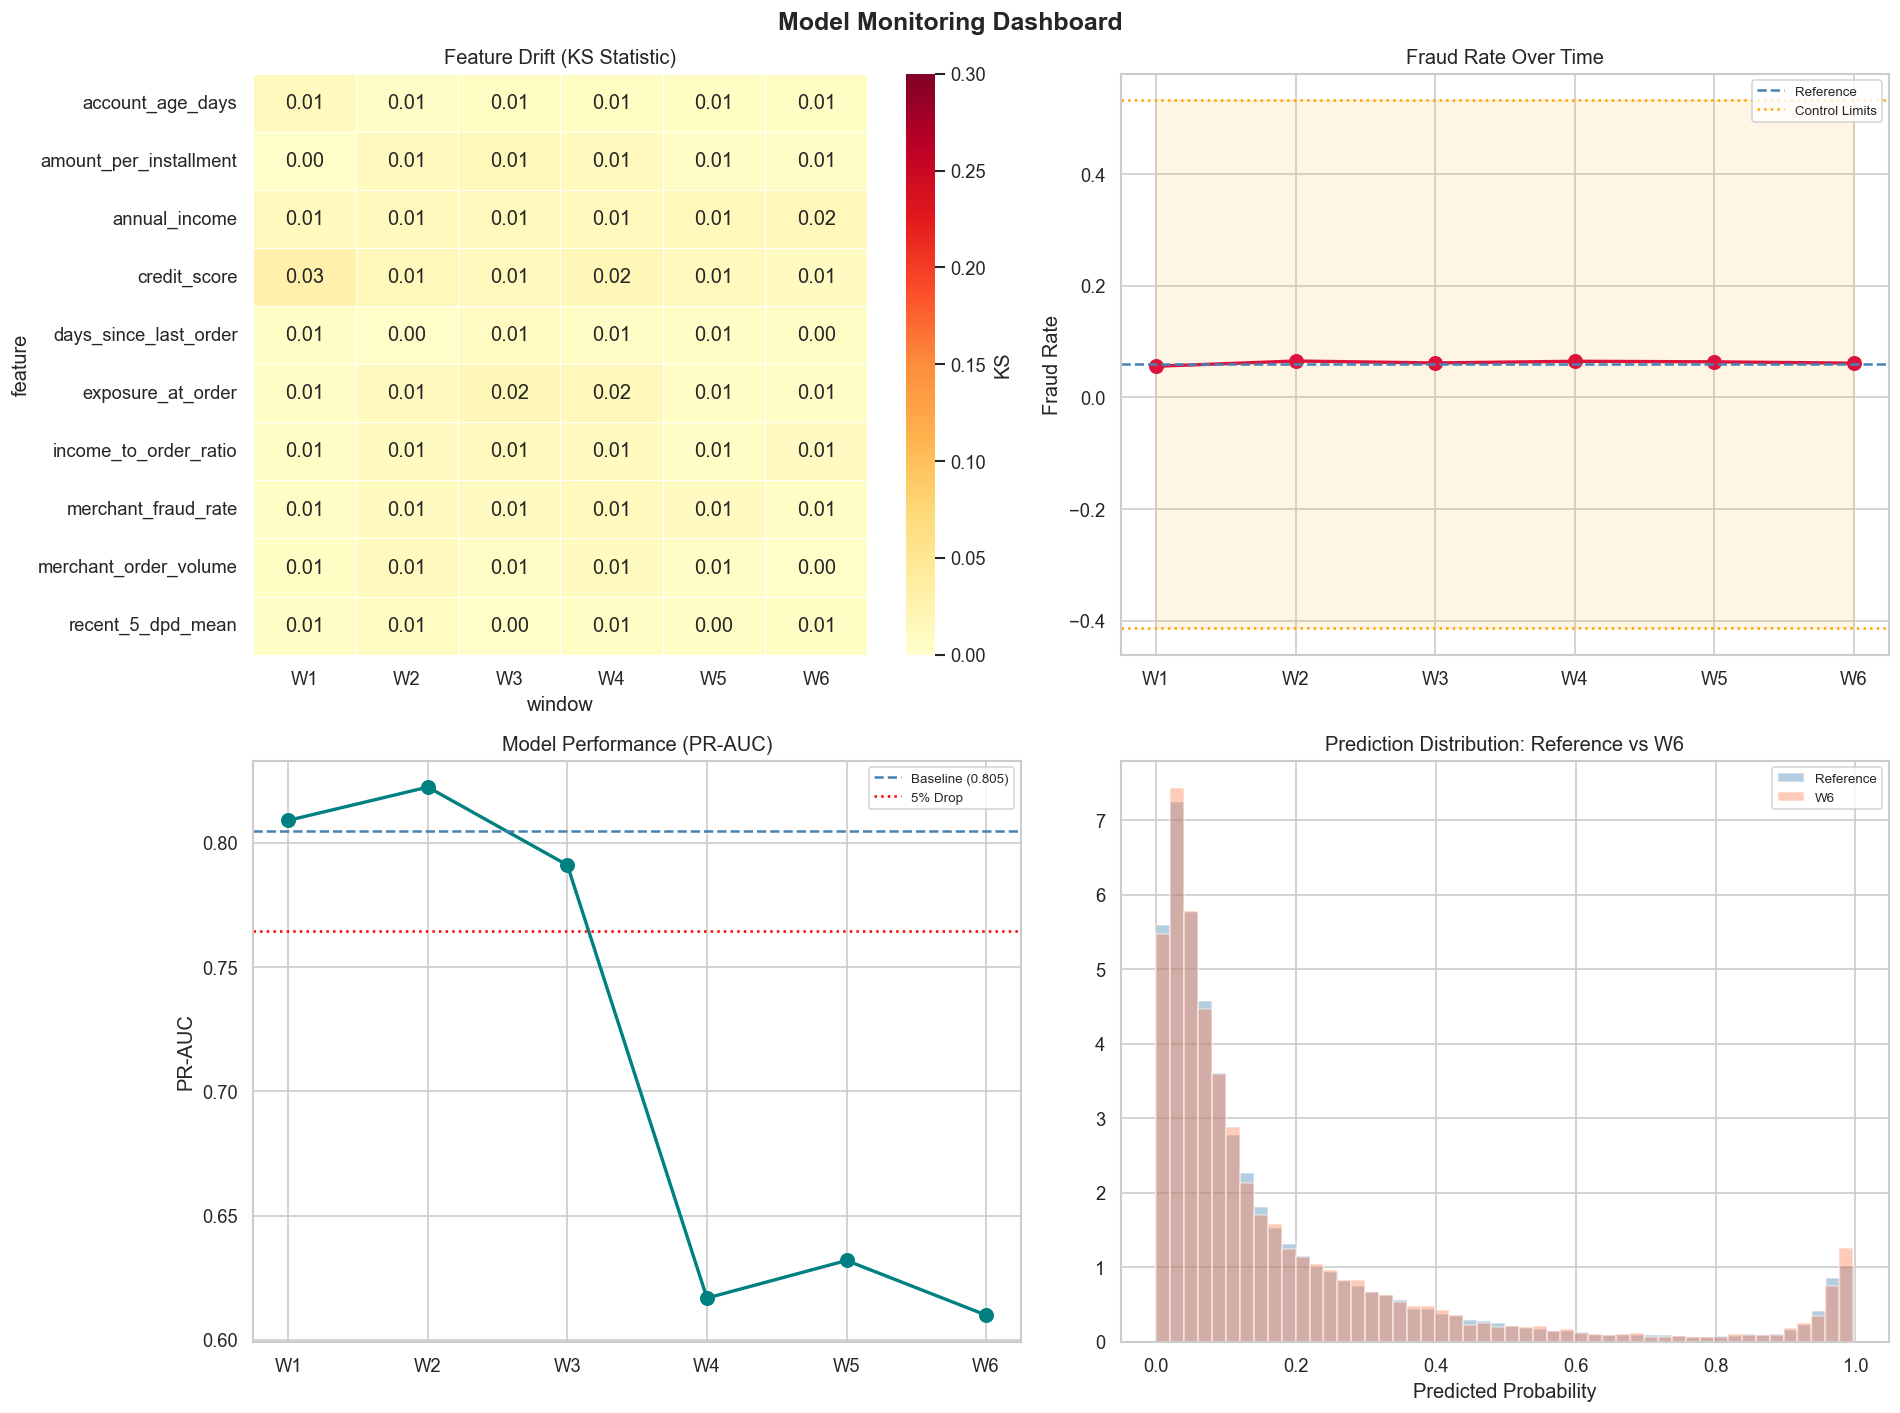

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Top-left: Feature drift heatmap
ax = axes[0, 0]
hm_data = drift_df.pivot_table(index="feature", columns="window", values="ks_stat", aggfunc="first")
sns.heatmap(hm_data, annot=True, fmt=".2f", cmap="YlOrRd", ax=ax,
            linewidths=0.5, vmin=0, vmax=0.3, cbar_kws={"label": "KS"})
ax.set_title("Feature Drift (KS Statistic)")

# Top-right: Fraud rate over time
ax = axes[0, 1]
ax.plot(concept_df["window"], concept_df["fraud_rate"], "o-", color="crimson", linewidth=2, markersize=8)
ax.axhline(ref_fraud_rate, color="steelblue", linestyle="--", label="Reference")
ax.axhline(upper_cl, color="orange", linestyle=":", label="Control Limits")
ax.axhline(lower_cl, color="orange", linestyle=":")
ax.fill_between(concept_df["window"], lower_cl, upper_cl, alpha=0.1, color="orange")
ax.set_title("Fraud Rate Over Time")
ax.set_ylabel("Fraud Rate")
ax.legend(fontsize=8)

# Bottom-left: PR-AUC over time
ax = axes[1, 0]
ax.plot(mon_perf["window"], mon_perf["pr_auc"], "o-", color="teal", linewidth=2, markersize=8)
ax.axhline(baseline_pr_auc, color="steelblue", linestyle="--", label=f"Baseline ({baseline_pr_auc:.3f})")
ax.axhline(baseline_pr_auc * 0.95, color="red", linestyle=":", label="5% Drop")
ax.set_title("Model Performance (PR-AUC)")
ax.set_ylabel("PR-AUC")
ax.legend(fontsize=8)

# Bottom-right: Prediction distribution shift
ax = axes[1, 1]
ax.hist(ref_proba, bins=50, alpha=0.4, density=True, label="Reference", color="steelblue")
last_window = list(window_probas.keys())[-1]
ax.hist(window_probas[last_window], bins=50, alpha=0.4, density=True, label=last_window, color="coral")
ax.set_title(f"Prediction Distribution: Reference vs {last_window}")
ax.set_xlabel("Predicted Probability")
ax.legend(fontsize=8)

plt.suptitle("Model Monitoring Dashboard", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

In [18]:
n_feature_drift = drift_df["drift_detected"].sum()
n_concept_alerts = concept_df["outside_control_limits"].sum()
n_perf_alerts = perf_df["perf_alert"].sum() if "perf_alert" in perf_df.columns else 0

if should_retrain:
    status = "CRITICAL"
elif n_feature_drift > 3 or n_concept_alerts > 0 or n_perf_alerts > 0:
    status = "WARNING"
else:
    status = "HEALTHY"

status_colors = {"HEALTHY": "\033[92m", "WARNING": "\033[93m", "CRITICAL": "\033[91m"}
reset = "\033[0m"

print("=" * 60)
print(f"  MONITORING STATUS: {status_colors.get(status, '')}{status}{reset}")
print("=" * 60)
print(f"  Feature drift signals:      {n_feature_drift} (across all features × windows)")
print(f"  Concept drift alerts:        {n_concept_alerts} windows outside control limits")
print(f"  Performance drop alerts:     {n_perf_alerts} windows with >5% PR-AUC drop")
print(f"  Auto-retrain triggered:      {'YES' if should_retrain else 'NO'}")
print("=" * 60)

  MONITORING STATUS: CRITICAL
  Feature drift signals:      0 (across all features × windows)
  Concept drift alerts:        0 windows outside control limits
  Performance drop alerts:     3 windows with >5% PR-AUC drop
  Auto-retrain triggered:      YES


## Key Findings

### Drift Signals

- **Feature drift** was assessed via Kolmogorov-Smirnov tests across 6 monitoring windows for the top 10 features. Features exceeding KS > 0.1 with p < 0.05 were flagged. The heatmap above shows which features drifted and when.
- **Concept drift** was tracked through the actual fraud rate in each window compared to the reference period's mean ± 2σ control limits. Windows breaching those limits indicate a shift in the underlying fraud pattern.
- **Model performance drift** was monitored via PR-AUC, precision, and recall. A >5% drop from the baseline PR-AUC triggers an alert.
- **Prediction distribution drift** was measured by applying KS tests to the model's output probabilities between reference and each monitoring window.

### Auto-Retrain Assessment

The auto-retrain logic checks three conditions:
1. Any feature with KS > 0.1 for 2+ consecutive windows
2. PR-AUC drop exceeding 5% from the baseline
3. Fraud rate outside control limits for 2+ consecutive windows

If any trigger fired, a retrained model was built on expanded data (reference + windows up to the trigger point) and evaluated on subsequent windows to demonstrate performance recovery.

### Production Recommendations

- **Monitoring cadence**: Run drift checks weekly (or per-batch for high-volume systems). Feature and prediction drift checks are cheap; performance drift requires ground-truth labels and can lag.
- **Alerting thresholds**: Start with KS > 0.1 for features, 5% PR-AUC drop for performance, and 2σ for concept drift. Tune these based on operational tolerance.
- **Retrain strategy**: Prefer expanding-window retraining over sliding-window to preserve rare-event signal. After retraining, run A/B validation before promoting the new model.
- **Modularization**: The drift detection and trigger functions in this notebook are designed to be extracted into a standalone monitoring script or Airflow DAG for scheduled execution.